
Loaded mof_extraction_failures_enum.csv
Total rows: 38408

PDF availability counts
Have value in main_pdf: 38117
Have value in si_pdf: 35784
Have both: 35493
Only main not si: 2624
Only si not main: 291
Neither: 0
After dropping rows with neither main_pdf nor si_pdf, rows left: 38408

article_trial_or_failure filter
Rows total before filter: 38408
Dropping rows where 'article_trial_or_failure' is neither yes nor no: 0
Rows left: 38408

Drop rows with required empties
Dropping rows where any of ['metal_1', 'linker_1', 'solvent_main', 'solvent_main_abbr'] is empty: 2352
Rows left: 36056

crystal_code cleaned
crystal_code changed: 36056
linker_1 trailing parens removed: 4499
linker_2 trailing parens removed: 29880
linker_3 trailing parens removed: 35983

temperature_c cleaning
Rows to drop due to temperature_c_text containing microwave or evaporation or slow: 287
Dropping rows with empty temperature_c after filling: 577
Rows left after temperature filters: 35192
metal_1: replaced ' × ' w

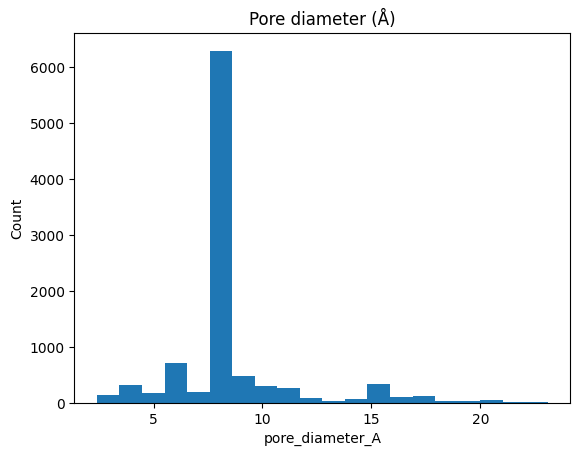


BET surface area (m²/g) distribution
BET_surface_area_m2g: numeric non empty count = 16952


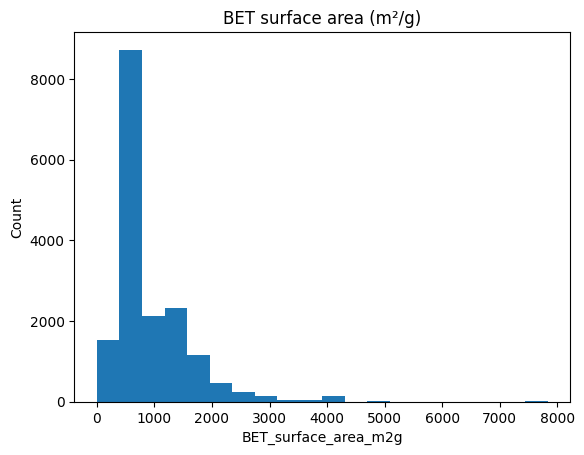


TGA decomposition temp (°C) distribution
tga_decomposition_temp_c: numeric non empty count = 17496


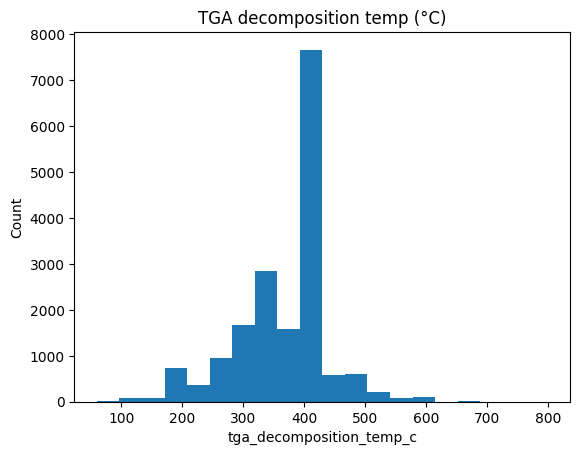


Topology report
Non-empty topology_code rows: 8377
Unique topology codes (case-insensitive): 141
Top 10 topology codes:
topology_code
bcu    1708
mtn    1121
fcu     928
dia     503
pcu     458
sql     335
sod     302
bnn     221
spn     192
acs     192

air_stable counts
yes: 11858
no: 439
not_reported: 20036
empty: 0
Top 10 values:
air_stable
not_reported    20036
yes             11858
nan              2859
no                439

water_stable counts
yes: 10253
no: 2773
not_reported: 19424
empty: 0
Top 10 values:
water_stable
not_reported    19424
yes             10253
no               2773
nan              2742

Wrote cleaned CSV to mof_extraction_failures_enum_1.csv


In [2]:

# Prints required stats and plots simple distributions.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
from collections import Counter
from pathlib import Path

# ---------- write ----------
in_path = Path("mof_extraction_failures_enum.csv")
out_path = in_path.with_name("mof_extraction_failures_enum_1.csv")

# ---------- helpers ----------
def is_filled(x):
    if x is None:
        return False
    if isinstance(x, float) and np.isnan(x):
        return False
    s = str(x).strip()
    return s != "" and s.lower() not in {"nan", "none"}

def filled_series(s):
    return s.apply(is_filled)

def count_changes(before, after):
    return int((before.astype(str) != after.astype(str)).sum())

def print_header(msg):
    print("\n" + "=" * 80)
    print(msg)
    print("=" * 80)

def safe_lower(x):
    try:
        return str(x).strip().lower()
    except Exception:
        return ""

def strip_trailing_parens(val, keep_when="(anhydrous)"):
    """Remove a trailing ' ( ... )' only if it is not the allowed exception.
       If the trailing parens looks like a formula, keep only the inside.
       Returns new_val, changed_flag
    """
    if not is_filled(val):
        return val, False
    s = str(val).strip()
    m = re.search(r"\s\(([^)]*)\)\s*$", s)
    if not m:
        return s, False
    inside = m.group(1).strip()
    if keep_when and s.endswith(f" {keep_when}"):
        return s, False
    # If inside looks like a formula, prefer the inside (e.g., '... (Ti(iPrO)4)' -> 'Ti(iPrO)4')
    if re.fullmatch(r"[A-Za-z0-9·\[\]\(\)]+", inside):
        return inside, True
    # Otherwise remove the whole trailing parenthetical
    new_s = re.sub(r"\s\([^)]*\)\s*$", "", s)
    return new_s, new_s != s

def remove_linker_trailing_parens(val):
    """For linker names like 'salicylic acid (H2L1)' remove trailing ' (H2L1)'"""
    if not is_filled(val):
        return val, False
    s = str(val).strip()
    new_s = re.sub(r"\s\([^)]*\)\s*$", "", s)
    return new_s, new_s != s

def normalize_x_to_middle_dot(s):
    if not is_filled(s):
        return s, False
    new_s = str(s).replace(" × ", "·")
    return new_s, new_s != s

def extract_digits_after_ccdc(val):
    """For crystal_code: if contains 'CCDC', keep the digits; else if mixed, keep digits only."""
    if not is_filled(val):
        return val, False
    s = str(val).strip()
    if "CCDC" in s.upper():
        digits = "".join(re.findall(r"\d+", s))
        return digits, s != digits
    if re.search(r"[A-Za-z]", s):
        digits = "".join(re.findall(r"\d+", s))
        return (digits if digits != "" else s), digits != s
    return s, False

def coerce_numeric(series):
    return pd.to_numeric(series, errors="coerce")

# ---------- read ----------

if not in_path.exists():
    raise FileNotFoundError("mof_extraction.csv not found in the current folder")

# load as strings to avoid unintended type casting
df = pd.read_csv(in_path, dtype=str, encoding="utf-8")
print_header(f"Loaded {in_path.name}")
print(f"Total rows: {len(df)}")

# ---------- 1) main_pdf / si_pdf presence stats ----------
for col in ["main_pdf", "si_pdf"]:
    if col not in df.columns:
        df[col] = np.nan

has_main = filled_series(df["main_pdf"])
has_si = filled_series(df["si_pdf"])

both = has_main & has_si
only_main = has_main & ~has_si
only_si = ~has_main & has_si
neither = ~has_main & ~has_si

print_header("PDF availability counts")
print(f"Have value in main_pdf: {int(has_main.sum())}")
print(f"Have value in si_pdf: {int(has_si.sum())}")
print(f"Have both: {int(both.sum())}")
print(f"Only main not si: {int(only_main.sum())}")
print(f"Only si not main: {int(only_si.sum())}")
print(f"Neither: {int(neither.sum())}")

# drop neither
df = df[~neither].copy()
print(f"After dropping rows with neither main_pdf nor si_pdf, rows left: {len(df)}")

# ---------- 2) article_trial_or_failure filtering ----------
col_atof = "article_trial_or_failure"
if col_atof not in df.columns:
    df[col_atof] = np.nan

valnorm = df[col_atof].apply(safe_lower)
keep_atof = valnorm.isin({"yes", "no"})
print_header("article_trial_or_failure filter")
print(f"Rows total before filter: {len(df)}")
print(f"Dropping rows where '{col_atof}' is neither yes nor no: {int((~keep_atof).sum())}")
df = df[keep_atof].copy()
print(f"Rows left: {len(df)}")

# ---------- 3) drop required empties ----------
required_cols = ["metal_1", "linker_1", "solvent_main", "solvent_main_abbr"]
for c in required_cols:
    if c not in df.columns:
        df[c] = np.nan

mask_required = filled_series(df["metal_1"]) & filled_series(df["linker_1"]) & filled_series(df["solvent_main"]) & filled_series(df["solvent_main_abbr"])
print_header("Drop rows with required empties")
print(f"Dropping rows where any of {required_cols} is empty: {int((~mask_required).sum())}")
df = df[mask_required].copy()
print(f"Rows left: {len(df)}")

# ---------- 4) light cleaning ----------
# 4a) crystal_code
if "crystal_code" not in df.columns:
    df["crystal_code"] = np.nan
before = df["crystal_code"].fillna("")
df["crystal_code"], _flags = zip(*df["crystal_code"].apply(extract_digits_after_ccdc))
df["crystal_code"] = pd.Series(df["crystal_code"]).astype(str).str.strip()
print_header("crystal_code cleaned")
print(f"crystal_code changed: {count_changes(before, df['crystal_code'])}")

# 4b) linker columns: remove trailing parenthetical
for lk in ["linker_1", "linker_2", "linker_3"]:
    if lk in df.columns:
        before = df[lk].fillna("")
        df[lk], _flags = zip(*df[lk].apply(remove_linker_trailing_parens))
        df[lk] = pd.Series(df[lk]).astype(str).str.strip()
        print(f"{lk} trailing parens removed: {count_changes(before, df[lk])}")

# 4c) temperature handling
for col in ["temperature_c", "temperature_c_text"]:
    if col not in df.columns:
        df[col] = np.nan

txt = df["temperature_c_text"].astype(str)
needs_25 = (~filled_series(df["temperature_c"])) & (
    txt.str.contains(r"\bRT\b", case=True, na=False) | txt.str.contains("room temperature", case=False, na=False)
)
df.loc[needs_25, "temperature_c"] = "25"

drop_temp_text = txt.str.contains("microwave", case=False, na=False) | \
                 txt.str.contains("evaporation", case=False, na=False) | \
                 txt.str.contains("slow", case=False, na=False)
print_header("temperature_c cleaning")
print(f"Rows to drop due to temperature_c_text containing microwave or evaporation or slow: {int(drop_temp_text.sum())}")
df = df[~drop_temp_text].copy()

still_empty_temp = ~filled_series(df["temperature_c"])
print(f"Dropping rows with empty temperature_c after filling: {int(still_empty_temp.sum())}")
df = df[~still_empty_temp].copy()
print(f"Rows left after temperature filters: {len(df)}")

# 4d) metals: replace ' × ' with '·' and strip trailing parens except ' (anhydrous)'
metal_cols = ["metal_1", "metal_2", "metal_3"]
for mc in metal_cols:
    if mc not in df.columns:
        df[mc] = np.nan

# normalize middle dot
for mc in metal_cols:
    before = df[mc].fillna("")
    df[mc], _flags = zip(*df[mc].apply(normalize_x_to_middle_dot))
    df[mc] = pd.Series(df[mc])
    print(f"{mc}: replaced ' × ' with '·' in {count_changes(before, df[mc].fillna(''))} rows")

# strip trailing parentheses with rule
for mc in metal_cols:
    before = df[mc].fillna("")
    new_vals = []
    changed_count = 0
    for v in df[mc]:
        nv, ch = strip_trailing_parens(v, keep_when="(anhydrous)")
        new_vals.append(nv)
        changed_count += 1 if ch else 0
    df[mc] = pd.Series(new_vals).astype(str).str.strip()
    print(f"{mc}: trailing parentheses handled in {changed_count} rows")

# 4e) metal standardization dictionary (to canonical like FeCl3·6H2O)
metal_map = {
    # Chlorides and oxychlorides
    "zrcl4": "ZrCl4",
    "zirconium tetrachloride": "ZrCl4",
    "zrocl2·8h2o": "ZrOCl2·8H2O",
    "zrocl2.8h2o": "ZrOCl2·8H2O",
    # Aluminum
    "alcl3·6h2o": "AlCl3·6H2O",
    "alcl3.6h2o": "AlCl3·6H2O",
    "aluminium nitrate nonahydrate": "Al(NO3)3·9H2O",
    # Iron
    "fecl3·6h2o": "FeCl3·6H2O",
    "iron(iii) chloride hexahydrate": "FeCl3·6H2O",
    "iron powder": "Fe",
    # Zinc
    "zinc nitrate hexahydrate": "Zn(NO3)2·6H2O",
    # Copper
    "cu(no3)2·h2o": "Cu(NO3)2·H2O",
    "cu(no3)2×h2o": "Cu(NO3)2·H2O",
    "copper(ii) nitrate dihydrate (2.5-hydrate)": "Cu(NO3)2·2.5H2O",
    # Indium
    "indium(iii) nitrate tetrahydrate-hemihydrate": "In(NO3)3·4.5H2O",
    # Rare earth hydroxides
    "gadolinium(iii) hydroxide": "Gd(OH)3",
    "dysprosium(iii) hydroxide": "Dy(OH)3",
    "holmium(iii) hydroxide": "Ho(OH)3",
    "erbium(iii) hydroxide": "Er(OH)3",
    # Titanium
    "tio(acac)2": "TiO(acac)2",
    "ti(i-propoxide)4": "Ti(iPrO)4",
    "ti(ipro)4": "Ti(iPrO)4",
    "tii(pro)4": "Ti(iPrO)4",
}

def canon_metal(val):
    if not is_filled(val):
        return val
    s = str(val).strip()
    s_norm = s.replace(" × ", "·")
    s_norm = re.sub(r"\s+", " ", s_norm).strip()
    key = s_norm.lower()
    if key in metal_map:
        return metal_map[key]
    # hydrate punctuation variant
    key2 = key.replace("·", ".")
    if key2 in metal_map:
        return metal_map[key2]
    return s_norm

for mc in metal_cols:
    before = df[mc].fillna("")
    df[mc] = df[mc].apply(canon_metal).astype(str).str.strip()
    print(f"{mc}: standardized entries changed: {count_changes(before, df[mc])}")

# final normalization of any stray ×
for mc in metal_cols:
    before = df[mc].fillna("")
    df[mc] = df[mc].str.replace(r"\s*×\s*", "·", regex=True)
    print(f"{mc}: final '×' to '·' normalization count: {count_changes(before, df[mc].fillna(''))}")

    
    # ---------- pore_diameter_A cleanup ----------
if "pore_diameter_A" in df.columns:
    pore_vals = pd.to_numeric(df["pore_diameter_A"], errors="coerce")
    mean_val = pore_vals.dropna().mean()
    if not np.isnan(mean_val):
        df.loc[pore_vals > 2 * mean_val, "pore_diameter_A"] = ""
    
# ---------- topology_code cleaning ----------
if "topology_code" not in df.columns:
    df["topology_code"] = np.nan

topo = df["topology_code"].fillna("").astype(str).str.strip()

# Identify which entries are not exactly three letters (A–Z)
# Identify which entries are either exactly three letters or three letters + '-' + one letter
valid_topology_pattern = r"^[A-Za-z]{3}(-[A-Za-z])?$"
invalid_mask = ~topo.str.match(valid_topology_pattern)

# Count and show representative invalid entries
invalid_examples = topo[invalid_mask].replace("", np.nan).dropna().unique()
print_header("topology_code cleanup")
print(f"Total rows checked: {len(df)}")
print(f"Entries with invalid (non-three-letter) topology_code: {invalid_mask.sum()}")

if len(invalid_examples) > 0:
    print("Examples of removed topology_code values:")
    print(", ".join(invalid_examples[:10]))
else:
    print("No invalid topology_code values found.")

# Set invalid ones to empty string
df.loc[invalid_mask, "topology_code"] = ""    

    
    
# ---------- 5) Summary tables ----------
print_header("Summary after cleaning and filtering")

if "doi" not in df.columns:
    df["doi"] = np.nan

papers_left = df["doi"].dropna().astype(str).str.strip().replace("", np.nan).dropna().nunique()
rows_left = len(df)
print(f"Papers left (unique doi): {papers_left}")
print(f"Rows left: {rows_left}")

yes_articles = df.loc[df[col_atof].str.strip().str.lower() == "yes", "doi"].dropna().astype(str).str.strip().nunique()
print(f"Articles with article_trial_or_failure == yes (unique doi): {yes_articles}")



    
    
def print_uniques_and_top(df, cols, title):
    print_header(title)
    for c in cols:
        if c in df.columns:
            series = df[c].dropna().astype(str).str.strip()
            series = series[series != ""]
            u = series.nunique()
            print(f"{c}: unique values = {u}")
            vc = series.value_counts().head(10)
            if len(vc) > 0:
                print("Top 10:")
                print(vc.to_string())
            else:
                print("Top 10: none")
        else:
            print(f"{c}: column not found")

print_uniques_and_top(df, ["metal_1", "metal_2", "metal_3"], "Unique metals")
print_uniques_and_top(df, ["linker_1", "linker_2", "linker_3"], "Unique linkers")
print_uniques_and_top(df, ["modulator_1", "modulator_2", "modulator_3"], "Unique modulators")
print_uniques_and_top(df, ["solvent_main_abbr"], "Unique solvent_main_abbr")
print_uniques_and_top(df, ["temperature_c"], "Unique temperature_c")
print_uniques_and_top(df, ["time_h"], "Unique time_h")
print_uniques_and_top(df, ["topology_code"], "Unique topology_code")

# Numeric distributions
def histogram_and_count(df, col, title):
    print_header(f"{title} distribution")
    series = df[col] if col in df.columns else pd.Series(dtype=str)
    nonempty = series.dropna().astype(str).str.strip()
    nonempty = nonempty[nonempty != ""]
    vals = pd.to_numeric(nonempty, errors="coerce")
    count_nonnull = int(vals.notna().sum())
    print(f"{col}: numeric non empty count = {count_nonnull}")
    if count_nonnull > 0:
        plt.figure()
        vals.dropna().astype(float).plot(kind="hist", bins=20, title=title)
        plt.xlabel(col)
        plt.ylabel("Count")
        plt.show()
    return count_nonnull

_ = histogram_and_count(df, "pore_diameter_A", "Pore diameter (Å)")
_ = histogram_and_count(df, "BET_surface_area_m2g", "BET surface area (m²/g)")
_ = histogram_and_count(df, "tga_decomposition_temp_c", "TGA decomposition temp (°C)")

# ---------- Topology report ----------
print_header("Topology report")

# Normalize: strip, drop empty, lower for case-insensitive counting
topo_norm = (
    df["topology_code"]
    .astype(str)
    .str.strip()
)
topo_nonempty = topo_norm[topo_norm != ""]
topo_counts = topo_nonempty.str.lower().value_counts()

print(f"Non-empty topology_code rows: {int(topo_counts.sum())}")
print(f"Unique topology codes (case-insensitive): {int(topo_counts.size)}")

print("Top 10 topology codes:")
print(topo_counts.head(10).to_string())

# Stability counts
def stability_counts(col):
    if col not in df.columns:
        print(f"{col}: column not found")
        return
    s = df[col].apply(safe_lower)
    s = s.replace("", np.nan)
    total_yes = int((s == "yes").sum())
    total_no = int((s == "no").sum())
    total_not_reported = int((s == "not_reported").sum())
    total_empty = int(s.isna().sum())
    print_header(f"{col} counts")
    print(f"yes: {total_yes}")
    print(f"no: {total_no}")
    print(f"not_reported: {total_not_reported}")
    print(f"empty: {total_empty}")
    vc = s.value_counts(dropna=False).head(10)
    print("Top 10 values:")
    print(vc.to_string())

stability_counts("air_stable")
stability_counts("water_stable")



# Replace NaN with empty string before saving
df = df.fillna("")

# Use UTF-8 with BOM to preserve all special symbols like "·"
df.to_csv(out_path, index=False, encoding="utf-8-sig")

print_header(f"Wrote cleaned CSV to {out_path.name}")



do deep cleaning for metal collumn

In [4]:
# Final metal normalization and pruning per your rules
import pandas as pd, numpy as np, re
from fractions import Fraction
from math import gcd
from pathlib import Path

IN = "mof_extraction_failures_enum_1.csv"
OUT = Path(IN).with_name(Path(IN).stem + "_2.csv")



def is_filled(x):
    if x is None: return False
    if isinstance(x, float) and np.isnan(x): return False
    return str(x).strip() != "" and str(x).strip().lower() not in {"nan","none"}

def fmt_frac(n: float) -> str:
    if float(n).is_integer(): return str(int(n))
    f = Fraction(n).limit_denominator(12)
    return f"{f.numerator}/{f.denominator}"

COMPLIANT = re.compile(r"^[\[\(]?[A-Z][a-z]?(?:[A-Za-z0-9\[\]\(\)]+)?(?:·(?:\d+(?:\.\d+)?(?:/\d+)?|x)H2O)?$", re.I)

FRAMEWORK_PAT = re.compile(r"\b(MOF|ZIF|UiO|HKUST|MIL|PCN|NU|IRMOF|NOTT|DUT|MOP)\b", re.I)
CLUSTER_PAT   = re.compile(r"\b(cluster|oxocluster|node|Zr6)\b", re.I)
TEMPLATE_PAT  = re.compile(r"\b(HDS|template|MXene)\b", re.I)
BTC_PAT       = re.compile(r"-\s*BTC\b", re.I)
ZNEG_PAT      = re.compile(r"\b(?:Zn|zinc)\s*[-/]\s*EG\b|\bzinc[- ]ethylene glycol\b", re.I)
SALT_PAT      = re.compile(r"\bsalt\b", re.I)
ACID_PAT      = re.compile(r"\bacid\b", re.I)

METAL_NAME_TO_SYM = {
    "lithium":"Li","sodium":"Na","potassium":"K","rubidium":"Rb","cesium":"Cs",
    "beryllium":"Be","magnesium":"Mg","calcium":"Ca","strontium":"Sr","barium":"Ba",
    "aluminum":"Al","aluminium":"Al","gallium":"Ga","indium":"In","thallium":"Tl",
    "germanium":"Ge","silicon":"Si","tin":"Sn","lead":"Pb","antimony":"Sb","bismuth":"Bi","boron":"B",
    "scandium":"Sc","yttrium":"Y","titanium":"Ti","zirconium":"Zr","hafnium":"Hf",
    "vanadium":"V","niobium":"Nb","tantalum":"Ta","chromium":"Cr","molybdenum":"Mo","tungsten":"W",
    "manganese":"Mn","technetium":"Tc","rhenium":"Re","iron":"Fe","ruthenium":"Ru","osmium":"Os",
    "cobalt":"Co","rhodium":"Rh","iridium":"Ir","nickel":"Ni","palladium":"Pd","platinum":"Pt",
    "copper":"Cu","silver":"Ag","gold":"Au","zinc":"Zn","cadmium":"Cd","mercury":"Hg",
    "lanthanum":"La","cerium":"Ce","praseodymium":"Pr","neodymium":"Nd","promethium":"Pm",
    "samarium":"Sm","europium":"Eu","gadolinium":"Gd","terbium":"Tb","dysprosium":"Dy",
    "holmium":"Ho","erbium":"Er","thulium":"Tm","ytterbium":"Yb","lutetium":"Lu",
    "thorium":"Th","uranium":"U",
    "ferrous":"Fe","ferric":"Fe","cuprous":"Cu","cupric":"Cu","stannous":"Sn","stannic":"Sn",
    "plumbous":"Pb","plumbic":"Pb","chromous":"Cr","chromic":"Cr","manganous":"Mn","manganic":"Mn",
    "cerous":"Ce","ceric":"Ce","cobaltous":"Co"
}
ADJ_OX = {"ferrous":2,"ferric":3,"cuprous":1,"cupric":2,"stannous":2,"stannic":4,"plumbous":2,"plumbic":4,
          "chromous":2,"chromic":3,"manganous":2,"manganic":3,"cerous":3,"ceric":4,"cobaltous":2}
COMMON_OX = {"Ag":1,"Cu":2,"Au":3,"Zn":2,"Cd":2,"Hg":2,"Al":3,"Ga":3,"In":3,"Tl":3,
             "Sc":3,"Y":3,"La":3,"Ce":3,"Pr":3,"Nd":3,"Sm":3,"Eu":3,"Gd":3,"Tb":3,"Dy":3,"Ho":3,"Er":3,"Tm":3,"Yb":3,"Lu":3,
             "Ti":4,"Zr":4,"Hf":4,"V":3,"Nb":5,"Ta":5,"Cr":3,"Mo":6,"W":6,"Mn":2,"Fe":3,"Co":2,"Ni":2,
             "Pb":2,"Sn":4,"Bi":3,"U":6,"Th":4,"Mg":2,"Ca":2,"Sr":2,"Ba":2,"Na":1,"K":1,"Li":1}
ROMAN = {"I":1,"II":2,"III":3,"IV":4,"V":5,"VI":6,"VII":7,"VIII":8,"IX":9,"X":10}
ANION = {
    "chloride":("Cl",-1),"bromide":("Br",-1),"iodide":("I",-1),"fluoride":("F",-1),
    "nitrate":("NO3",-1),"perchlorate":("ClO4",-1),"chlorate":("ClO3",-1),
    "acetate":("CH3COO",-1),"trifluoroacetate":("CF3COO",-1),"formate":("HCOO",-1),"benzoate":("PhCOO",-1),
    "triflate":("OTf",-1),"trifluoromethanesulfonate":("OTf",-1),"tosylate":("OTs",-1),"p-toluenesulfonate":("OTs",-1),
    "tetrafluoroborate":("BF4",-1),"hexafluorophosphate":("PF6",-1),
    "hexafluoroantimonate":("SbF6",-1),"hexafluoroarsenate":("AsF6",-1),
    "thiocyanate":("SCN",-1),"cyanide":("CN",-1),
    "hydroxide":("OH",-1),
    "carbonate":("CO3",-2),"sulfate":("SO4",-2),"sulphate":("SO4",-2),"oxalate":("C2O4",-2),
    "oxide":("O",-2)
}
MONO_ANIONS = {"Cl","Br","I","F","O","H","N","C","S"}

HYDRATE_WORD = {
    "monohydrate":1,"dihydrate":2,"trihydrate":3,"tetrahydrate":4,"pentahydrate":5,
    "hexahydrate":6,"heptahydrate":7,"octahydrate":8,"nonahydrate":9,"decahydrate":10,
    "sesquihydrate":1.5,"hemihydrate":0.5,"hydrate":"x","hemi(pentahydrate)":2.5
}
PREFIX_TO_NUM = {"mono":1,"di":2,"tri":3,"tetra":4,"penta":5,"hexa":6,"hepta":7,"octa":8,"nona":9,"deca":10}

def clean_unicode(s): 
    if not is_filled(s): return s
    t = str(s).replace("μ","u").replace("µ","u").replace("–","-").replace("—","-").replace("· ", "·")
    t = t.replace("{","(").replace("}",")")
    t = re.sub(r"\bc+admium\b","cadmium", t, flags=re.I)
    return t

def replace_tokens(t):
    if not is_filled(t): return t
    s = str(t)
    s = re.sub(r"\bCH3CO2\b", "CH3COO", s, flags=re.I)
    s = re.sub(r"\(OAc\)", "(CH3COO)", s, flags=re.I)
    s = re.sub(r"\(OAC\)", "(CH3COO)", s, flags=re.I)
    s = re.sub(r"\(Ac\)",  "(CH3COO)", s, flags=re.I)
    s = re.sub(r"\(NO33", "(NO3)3", s, flags=re.I)
    s = s.replace("$","·")
    s = re.sub(r"\bOH2\b","H2O", s); s = re.sub(r"\(OH2\)","(OH)2", s)
    s = re.sub(r"\bTi\(i\-?OPr\)4\b", "Ti(OiPr)4", s, flags=re.I)
    s = re.sub(r"\btitanium\s+isopropoxyde\b", "Ti(OiPr)4", s, flags=re.I)
    s = re.sub(r"\btitanium\s+isopropylate\b", "Ti(OiPr)4", s, flags=re.I)
    s = re.sub(r"\btitanium\s+(tetra\-)?isopropoxide\b", "Ti(OiPr)4", s, flags=re.I)
    return s

def unify_parentheses(s):
    if not is_filled(s): return s
    t = str(s)
    t = re.sub(r"\.(\d+)\s*\(H2O\)", r"·\1H2O", t)
    t = re.sub(r"·\s*(\d+(?:\.\d+)?)\s*\(H2O\)", r"·\1H2O", t)
    t = re.sub(r"·\s*\(H2O\)", "·1H2O", t)
    t = re.sub(r"\bdihydrate\s+and\s+a\s+half\b", "·2.5H2O", t, flags=re.I)
    t = re.sub(r"-half\s*·\s*H2O", "·0.5H2O", t, flags=re.I)
    t = re.sub(r"[- ]·\s*H2O", "·1H2O", t, flags=re.I)
    t = re.sub(r"[\)\]]+$","", t)
    return t

QUAL_TAIL = re.compile(r"[,\s;]+(anhydrous|anhydrodous|solution|aq\.?|aqueous|powder|wire|foil|granules?|beads?|shot|pellets?|suspension|wastewater|leachate|precursor.*|seed[s]?|template.*|stock.*|ethanolic|nanosized|crystals?|nanowires?|nanosheets?)$", re.I)
def strip_qualifiers(s):
    if not is_filled(s): return s
    out = str(s).strip()
    while True:
        new = re.sub(QUAL_TAIL, "", out).strip()
        if new == out: break
        out = new
    out = re.sub(r"\b\d+(\.\d+)?\s*%$","", out).strip()
    out = re.sub(r"\bin\s*\d+(\.\d+)?\s*M\s*[A-Za-z0-9\(\)]+","", out).strip()
    return out

def cut_descriptor_tails(s):
    if not is_filled(s): return s
    t = str(s)
    t = re.sub(r"\b(heterometallic ring|polymer|intermediate|source|magnet|tubular monolith)\b.*$","",t,flags=re.I)
    t = re.sub(r"^\s*\d+[a-z]?\s*$","",t,flags=re.I)
    return t.strip()

def normalize_dots_and_h2o(s):
    if not is_filled(s): return s
    out = str(s)
    out = re.sub(r"\s*[·∙•⋅xX\.]\s*([0-9]+(?:\.\d+)?(?:/\d+)?|n|x)\s*H\s*2\s*O", lambda m: "·" + m.group(1).lower().replace("n","x") + "H2O", out, flags=re.I)
    out = re.sub(r"([A-Za-z0-9\)\]])\s+((?:\d+(?:\.\d+)?(?:/\d+)?|x)\s*H\s*2\s*O\b)", lambda m: m.group(1) + "·" + re.sub(r"\s*","", m.group(2)), out, flags=re.I)
    out = re.sub(r"·\s*\(H2O\)","·1H2O", out)
    out = re.sub(r"·\s*H2O\b","·1H2O", out)
    out = re.sub(r"H\s*2\s*O","H2O", out, flags=re.I)
    out = re.sub(r"·{2,}","·", out)
    return out.strip()

def consolidate_hydrates(s):
    if not is_filled(s): return s
    t = str(s)
    dots = re.findall(r"·([0-9]+(?:\.\d+)?(?:/\d+)?|x)H2O", t, re.I)
    pars = re.findall(r"\(H2O\)\s*([0-9]+(?:\.\d+)?)+", t, re.I)
    total, unknown = 0.0, False
    for d in dots:
        d = d.lower()
        if d == "x": unknown = True
        elif "/" in d:
            try:
                a,b = d.split("/",1); total += float(a)/float(b)
            except: unknown = True
        else:
            total += float(d)
    for p in pars: total += float(p)
    t = re.sub(r"·([0-9]+(?:\.\d+)?(?:/\d+)?|x)H2O","",t,flags=re.I)
    t = re.sub(r"\(H2O\)\s*([0-9]+(?:\.\d+)?)+","",t,flags=re.I)
    t = re.sub(r"\s+"," ",t).strip()
    if unknown and total==0: return t+"·xH2O"
    if unknown and total>0:  return t+"·xH2O"
    return t + (f"·{fmt_frac(total)}H2O" if total>0 else "")

def strip_nonwater_adducts(s):
    if not is_filled(s): return s
    out = str(s)
    while True:
        new = re.sub(r"·\s*(\d+(?:\.\d+)?)?\s*(?!H2O\b)[A-Za-z][A-Za-z0-9\(\)]+","",out)
        if new == out: break
        out = new
    return out.strip()

def simplify_polyoxo_acids(s):
    if not is_filled(s): return s
    t = str(s)
    m = re.search(r"\[([^\]]+)\]", t)
    if m:
        inside = m.group(1)
        m2 = re.search(r"(Mo|W|V|Re)\d+O\d+", inside)
        if m2: t = inside[m2.start():] + t[m.end():]
    m3 = re.search(r"(Mo|W|V|Re)\d+O\d+", t)
    if m3: t = t[m3.start():]
    return t.strip()

def strip_leading_cations_for_complex(s):
    if not is_filled(s): return s
    t = re.sub(r"^\s*\((?:Me\d*N|Et4N|NBu4|Bu3NH|TBA)\)\d*\s*(?=[\[\(])","", str(s), flags=re.I)
    m = re.search(r"\[[^\]]+\]", t)
    if m:
        head = t[:m.start()].strip()
        if re.fullmatch(r"(?:(?:\(?NH4\)?|K|Na|Li|Rb|Cs)\d*\s*)+", head, flags=re.I):
            t = t[m.start():] + t[m.end():]
    return t

def drop_counterions_after_complex(s):
    if not is_filled(s): return s
    t = str(s)
    t = re.sub(r"^\[([^\]]+)\]\s*(PF6|BF4|BPh4|ClO4|NO3|Cl)(?:\s*·[A-Za-z0-9\(\)]+)*$", r"\1", t, flags=re.I)
    t = re.sub(r"^(.*\))\s*(PF6|BF4|BPh4|ClO4|NO3|Cl)(?:\s*·[A-Za-z0-9\(\)]+)*$", r"\1", t, flags=re.I)
    return t

def final_trim(s):
    if not is_filled(s): return s
    t = re.sub(r"\s+"," ", str(s)).strip()
    t = re.sub(r"[,\.;:]+$","", t)
    return t

TEXT_SALT_PAT = re.compile(
    r"^\s*(?P<metal>[A-Za-z]+)\s*(?:\(\s*(?P<roman>[ivxIVX]+)\s*\))?\s+(?P<anion>[A-Za-z\- ]+?)(?:\s|$)", re.I
)

def parse_hydrate_words(rest: str):
    if not is_filled(rest): return None
    r = rest.lower()
    m = re.search(r"hemi\((mono|di|tri|tetra|penta|hexa|hepta|octa|nona|deca)hydrate\)", r)
    if m: return 0.5 * {"mono":1,"di":2,"tri":3,"tetra":4,"penta":5,"hexa":6,"hepta":7,"octa":8,"nona":9,"deca":10}[m.group(1)]
    m2 = re.search(r"\b(\d+(?:\.\d+)?)\s*-\s*hydrate\b", r)
    if m2: return float(m2.group(1))
    for w,n in HYDRATE_WORD.items():
        if re.search(rf"\b{re.escape(w)}\b", r): return n
    if re.search(r"·\s*H2O", rest): return 1
    return None

def build_stoich(m_sym, ox, anion_formula, anion_charge):
    c = abs(anion_charge)
    g = gcd(int(ox), c)
    a = c // g
    b = int(ox) // g
    if anion_formula in MONO_ANIONS:
        return f"{m_sym}{a if a>1 else ''}{anion_formula}{b if b>1 else ''}"
    return f"{m_sym}{a if a>1 else ''}({anion_formula}){b if b>1 else ''}"

def snap_special_cores(s):
    x = s
    x = re.sub(r"\bzirconyl\s+nitrate\b", "ZrO(NO3)2", x, flags=re.I)
    x = re.sub(r"\bzirconyl\s+chloride\b", "ZrOCl2", x, flags=re.I)
    x = re.sub(r"\buranyl\s+nitrate\b",   "UO2(NO3)2", x, flags=re.I)
    return x

def text_salt_to_formula(name: str):
    if not is_filled(name): return None
    s0 = snap_special_cores(str(name).strip())
    m = TEXT_SALT_PAT.match(s0)
    if not m: return None
    metal_word = m.group("metal"); roman = m.group("roman"); anion_words = m.group("anion")
    m_sym = METAL_NAME_TO_SYM.get(metal_word.lower())
    if not m_sym:
        if metal_word.lower() in ADJ_OX: m_sym = METAL_NAME_TO_SYM.get(metal_word.lower(), None) or metal_word.title()
        else: return None
    if roman:
        ox = ROMAN.get(roman.upper()); 
        if ox is None: return None
    elif metal_word.lower() in ADJ_OX:
        ox = ADJ_OX[metal_word.lower()]
    else:
        ox = COMMON_OX.get(m_sym); 
        if ox is None: return None

    akey = anion_words.lower().strip().replace("-", " ")
    akey = re.sub(r"\s+(hydrate|salt|solution).*$","", akey).strip()
    if akey.endswith(" acid"):
        acid = akey[:-5].strip()
        akey = {"acetic":"acetate","formic":"formate","benzoic":"benzoate"}.get(acid, akey)

    found = None
    for k,(form,chg) in ANION.items():
        if re.search(rf"\b{k}\b", akey): found = k; break
    if not found: return None

    an_form, an_charge = ANION[found]
    core = build_stoich(m_sym, ox, an_form, an_charge)

    n_h2o = parse_hydrate_words(s0)
    if n_h2o is None:
        m2 = re.search(r"·\s*([0-9]+(?:\.\d+)?(?:/\d+)?|x)\s*H2O", s0, re.I)
        if m2: return f"{core}·{m2.group(1)}H2O"
        if re.search(r"·\s*H2O", s0): return core + "·1H2O"
        return core
    if n_h2o == "x": return core + "·xH2O"
    return core + f"·{fmt_frac(float(n_h2o))}H2O"

FORMULA_TOKEN = re.compile(r"[A-Z][A-Za-z]?(?:[A-Za-z0-9\[\]\(\)]+)(?:·(?:\d+(?:\.\d+)?(?:/\d+)?|x)H2O)?")
def pick_first_formula(s):
    toks = FORMULA_TOKEN.findall(s)
    toks = [t for t in toks if not re.fullmatch(r"\(*[IVXivx]+\)*", t)]
    return toks[0] if toks else None

# manual maps you listed (ensure not non-compliant)
TEXT_SNAPS = {
    "zirconium acetylacetonate":"Zr(acac)4",
    "zirconium dichloride oxide octahydrate":"ZrOCl2·8H2O",
    "zirconium oxychloride octahydrate":"ZrOCl2·8H2O",
    "zirconium tetrachloride (anhydrous":"ZrCl4",
    "zirconyl chloride":"ZrOCl2",
    "ni(no3)2 hydrate":"Ni(NO3)2·xH2O",
    "tb(no3)3 0·5h2o":"Tb(NO3)3·0.5H2O",
    "ti(oipr)4":"Ti(OiPr)4",
    "ti(oipr)4,":"Ti(OiPr)4",
    "ferric trichloride hexahydrate":"FeCl3·6H2O",
    "hydrated copper nitrate":"Cu(NO3)2·xH2O",
    "iron fine":"Fe",
    "iron metal":"Fe",
    "nickel acetylacetonate":"Ni(acac)2",
    "nickel dichloride hexahydrate":"NiCl2·6H2O",
}

def normalize_entry(v: str) -> str:
    if not is_filled(v): return v
    s = clean_unicode(v)
    s = replace_tokens(s)
    s = unify_parentheses(s)
    s = strip_qualifiers(s)
    s = cut_descriptor_tails(s)

    if re.fullmatch(r"\(*[IVXivx]+\)*", s.strip()):  # orphan Roman
        return ""

    key = s.lower().strip()
    if key in TEXT_SNAPS:
        s = TEXT_SNAPS[key]

    if not re.match(r"^[A-Z][a-z]?\b", s):
        tok = pick_first_formula(s)
        if tok: s = tok

    cand = text_salt_to_formula(s)
    if cand: s = cand

    s = simplify_polyoxo_acids(s)
    s = strip_leading_cations_for_complex(s)
    s = drop_counterions_after_complex(s)

    s = normalize_dots_and_h2o(s)
    s = consolidate_hydrates(s)
    s = strip_nonwater_adducts(s)
    s = normalize_dots_and_h2o(s)
    s = consolidate_hydrates(s)

    s = final_trim(s)
    if re.fullmatch(r"\(*[IVXivx]+\)*", s): s = ""
    return s

# ---------- run ----------
df = pd.read_csv(IN, dtype=str)

# overwrite normalized metals
for col in ["metal_1","metal_2","metal_3"]:
    if col in df.columns:
        df[col] = df[col].astype(str).apply(normalize_entry)

# drop rows if any metal column contains framework/BTC/Zn-EG/acid/salt
def row_should_drop(row):
    for c in ["metal_1","metal_2","metal_3"]:
        if c not in row: continue
        val = row[c]
        if not is_filled(val): continue
        if FRAMEWORK_PAT.search(val) or CLUSTER_PAT.search(val) or TEMPLATE_PAT.search(val): return True
        if BTC_PAT.search(val) or ZNEG_PAT.search(val): return True
        if SALT_PAT.search(val) or ACID_PAT.search(val): return True
    return False

drop_mask0 = df.apply(row_should_drop, axis=1)
dropped0 = int(drop_mask0.sum())
df = df[~drop_mask0].copy()

# 1) drop if metal_1 is NaN or empty
drop_mask_nan = ~df["metal_1"].apply(is_filled)
dropped_nan = int(drop_mask_nan.sum())
df = df[~drop_mask_nan].copy()

# 2) drop if metal_1 non-compliant
noncomp_m1_vals = set(v.strip() for v in df["metal_1"].astype(str) if v.strip() and not COMPLIANT.fullmatch(v.strip()))
drop_mask_nc = df["metal_1"].astype(str).str.strip().isin(noncomp_m1_vals)
dropped_nc = int(drop_mask_nc.sum())
df = df[~drop_mask_nc].copy()

# 3) drop if metal_1 value occurs once and length ≤ 10 and has no '(' or ')'
m1_clean = df["metal_1"].astype(str).str.strip()
counts = m1_clean.value_counts()
singles = set(counts[counts==1].index)
def is_unique_short_no_paren(x):
    x = str(x).strip()
    if x in singles and len(x) <= 10 and ("(" not in x and ")" not in x):
        return True
    return False
drop_mask_unique = m1_clean.apply(is_unique_short_no_paren)
dropped_unique = int(drop_mask_unique.sum())
df = df[~drop_mask_unique].copy()

# save
df = df.fillna("")
df.to_csv(OUT, index=False, encoding="utf-8-sig")

# stats
print(f"Dropped framework/BTC/Zn-EG/acid/salt rows: {dropped0}")
print(f"Dropped metal_1 NaN/empty rows: {dropped_nan}")
print(f"Dropped metal_1 non-compliant rows: {dropped_nc}")
print(f"Dropped metal_1 unique-short-no-paren rows: {dropped_unique}")
print(f"Rows left: {len(df)}")

# metal_1 stats
m1 = df["metal_1"].astype(str).str.strip()
m1 = m1[m1!=""]
uniq = m1.nunique()
print(f"Unique metal_1 values: {uniq}")

vc = m1.value_counts()
print("\nTop 20 metal_1:")
print(vc.head(20).to_string())

print("\nLeast 20 metal_1:")
print(vc.sort_values(ascending=True).head(20).to_string())


Dropped framework/BTC/Zn-EG/acid/salt rows: 66
Dropped metal_1 NaN/empty rows: 3076
Dropped metal_1 non-compliant rows: 8289
Dropped metal_1 unique-short-no-paren rows: 17
Rows left: 23744
Unique metal_1 values: 455

Top 20 metal_1:
metal_1
ZrCl4               2961
Zn(NO3)2·6H2O       1888
AlCl3·6H2O          1323
Al(NO3)3·9H2O        993
Cu(NO3)2·3H2O        906
Zn(CH3COO)2·2H2O     858
TiO2                 697
Cd(NO3)2·4H2O        528
Co(NO3)2·6H2O        486
Bi(NO3)3·5H2O        397
ZnCl2                346
CuCl2·2H2O           334
ZrOCl2·8H2O          332
Co(CH3COO)2·4H2O     262
CoCl2·6H2O           259
La(NO3)3·6H2O        252
Ni(NO3)2·6H2O        239
Ho(NO3)3·5H2O        231
FeCl3·6H2O           227
La2O3                225

Least 20 metal_1:
metal_1
Cd(ClO4)2           1
ZnCl2·5/2H2O        1
Silver(I)           1
Co(H2IDC)2]·2H2O    1
Pd(CH3COO)2         1
Ru2(mand)4          1
Ru2(OBz)4           1
Rh2(esp)2           1
Fe(NO3)3            1
Sm(CH3COO)3         1
Nd(ClO4)3·6H